INFO:__main__:Connexion à MongoDB...
INFO:__main__:15000 documents récupérés.
Prétraitement contenus: 100%|██████████| 15000/15000 [00:11<00:00, 1279.08it/s]
INFO:__main__:Chargement du modèle AraBERT...
INFO:__main__:Utilisation du device: cpu
Méthode du coude:   0%|          | 0/20 [00:00<?, ?it/s]D:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 512 or by setting the environment variable OMP_NUM_THREADS=1
  warnings.warn(
Méthode du coude:   5%|▌         | 1/20 [00:09<03:07,  9.89s/it]D:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 512 or by setting the environment variable OMP_NUM_THREADS=1
  warnings.warn(
M

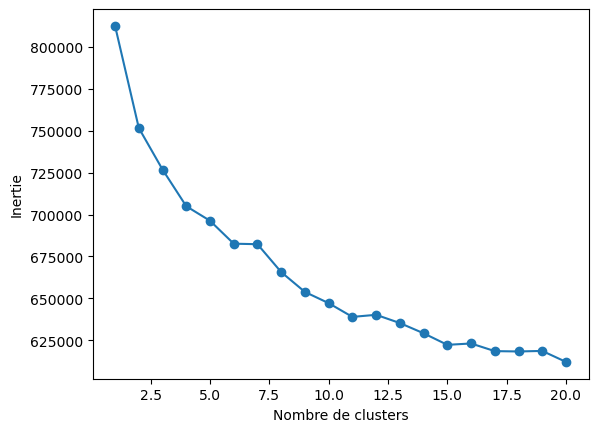

Méthode silhouette:   0%|          | 0/19 [00:00<?, ?it/s]D:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 512 or by setting the environment variable OMP_NUM_THREADS=1
  warnings.warn(
Méthode silhouette:   5%|▌         | 1/19 [00:04<01:20,  4.48s/it]D:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 512 or by setting the environment variable OMP_NUM_THREADS=1
  warnings.warn(
Méthode silhouette:  11%|█         | 2/19 [00:08<01:08,  4.05s/it]D:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than 

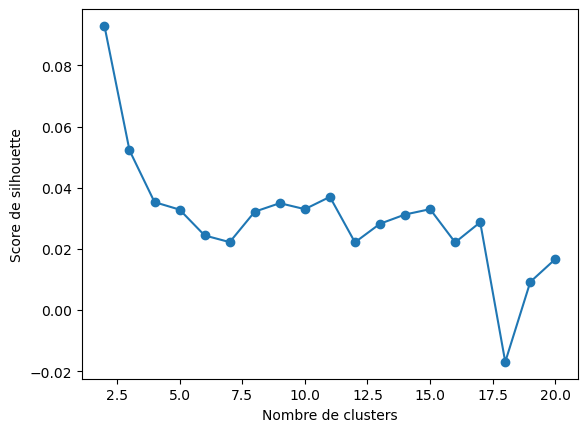

INFO:__main__:Nombre optimal de clusters: 12
D:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 512 or by setting the environment variable OMP_NUM_THREADS=1
  warnings.warn(


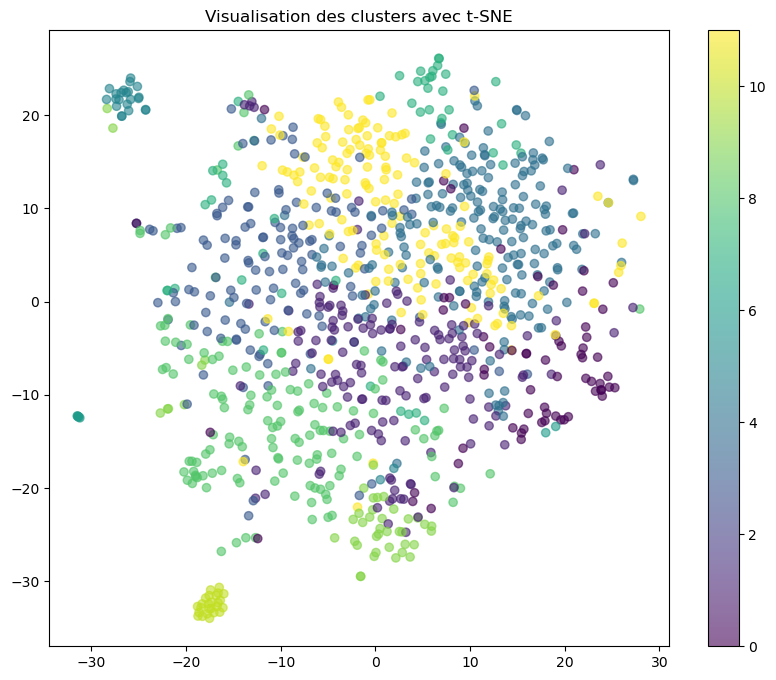

INFO:__main__:Clusters enregistrés dans MongoDB


In [1]:
import re
import nltk
from nltk.corpus import stopwords
from pymongo import MongoClient, UpdateOne
import numpy as np
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import torch
from transformers import AutoTokenizer, AutoModel
from joblib import Parallel, delayed
from tqdm import tqdm
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from Levenshtein import distance as levenshtein_distance
from nltk.stem.isri import ISRIStemmer
import logging

# Configuration du logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Télécharger les stopwords pour la langue arabe
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('arabic'))
stemmer = ISRIStemmer()

# Expressions régulières compilées
punctuation_re = re.compile(r'[^\w\s]')
digits_re = re.compile(r'\d+')

def get_data_from_mongodb():
    logger.info("Connexion à MongoDB...")
    try:
        client = MongoClient('localhost', 27017)
        db = client['dataset']
        collection = db['LesArticles']
        documents = list(collection.find({}))
        logger.info(f"{len(documents)} documents récupérés.")
        return db, documents
    except Exception as e:
        logger.error(f"Erreur MongoDB: {e}")
        return None, []

def preprocess_text(text, stop_words):
    if not text:
        return ""
    text = text.lower()
    text = punctuation_re.sub('', text)
    text = digits_re.sub('', text)
    words = [stemmer.stem(word) for word in text.split() if word not in stop_words]
    return " ".join(words)

def get_arabert_embeddings(texts, batch_size=32):
    logger.info("Chargement du modèle AraBERT...")
    try:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        logger.info(f"Utilisation du device: {device}")

        tokenizer = AutoTokenizer.from_pretrained('aubmindlab/bert-base-arabertv02')
        model = AutoModel.from_pretrained('aubmindlab/bert-base-arabertv02').to(device)
        model.eval()

        def process_batch(batch):
            inputs = tokenizer(batch, return_tensors='pt', truncation=True, padding=True, max_length=256).to(device)
            with torch.no_grad():
                outputs = model(**inputs)
            attention_mask = inputs['attention_mask'].unsqueeze(-1)
            last_hidden = outputs.last_hidden_state
            sum_embeddings = torch.sum(last_hidden * attention_mask, dim=1)
            sum_mask = torch.sum(attention_mask, dim=1)
            return (sum_embeddings / sum_mask).cpu().numpy()

        results = Parallel(n_jobs=1)(  # mettre -1 si plusieurs GPU disponibles
            delayed(process_batch)(texts[i:i + batch_size])
            for i in tqdm(range(0, len(texts), batch_size), desc="Embeddings")
        )

        return np.vstack(results)
    except Exception as e:
        logger.error(f"Erreur génération embeddings: {e}")
        return None

def elbow_method(embeddings, max_k):
    inertia = []
    for k in tqdm(range(1, max_k+1), desc="Méthode du coude"):
        kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=100)
        kmeans.fit(embeddings)
        inertia.append(kmeans.inertia_)
    plt.plot(range(1, max_k+1), inertia, marker='o')
    plt.xlabel('Nombre de clusters')
    plt.ylabel('Inertie')
    plt.show()
    diff = np.diff(inertia)
    return np.argmax(diff) + 2

def silhouette_method(embeddings, max_k):
    scores = []
    for k in tqdm(range(2, max_k+1), desc="Méthode silhouette"):
        kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=100)
        labels = kmeans.fit_predict(embeddings)
        scores.append(silhouette_score(embeddings, labels))
    plt.plot(range(2, max_k+1), scores, marker='o')
    plt.xlabel('Nombre de clusters')
    plt.ylabel('Score de silhouette')
    plt.show()
    return np.argmax(scores) + 2

def levenshtein_similarity(text1, text2):
    text1 = punctuation_re.sub('', text1.lower())
    text2 = punctuation_re.sub('', text2.lower())
    max_len = max(len(text1), len(text2))
    return 1 - (levenshtein_distance(text1, text2) / max_len) if max_len > 0 else 1.0

def calculate_similarities(cluster_texts, embeddings):
    lev_sim = np.zeros((len(cluster_texts), len(cluster_texts)))
    for i in range(len(cluster_texts)):
        for j in range(i, len(cluster_texts)):
            sim = levenshtein_similarity(cluster_texts[i], cluster_texts[j])
            lev_sim[i][j] = lev_sim[j][i] = sim
    bert_sim = cosine_similarity(embeddings)
    return lev_sim, bert_sim

def cluster_and_display(db, documents):
    titles = [doc.get('title', '') for doc in documents]
    contents = [doc.get('content', '') for doc in documents]

    processed_titles = Parallel(n_jobs=-1)(
        delayed(preprocess_text)(title, stop_words)
        for title in tqdm(titles, desc="Prétraitement titres")
    )
    processed_contents = Parallel(n_jobs=-1)(
        delayed(preprocess_text)(content, stop_words)
        for content in tqdm(contents, desc="Prétraitement contenus")
    )

    embeddings = get_arabert_embeddings(processed_contents)
    if embeddings is None:
        return

    pca = PCA(n_components=100, svd_solver='randomized')
    embeddings_reduced = pca.fit_transform(embeddings)

    max_k = min(20, len(documents)//10)
    k_elbow = elbow_method(embeddings_reduced, max_k)
    k_silhouette = silhouette_method(embeddings_reduced, max_k)
    optimal_k = max(k_elbow, k_silhouette)
    logger.info(f"Nombre optimal de clusters: {optimal_k}")

    kmeans = MiniBatchKMeans(n_clusters=optimal_k, random_state=42, batch_size=100)
    clusters = kmeans.fit_predict(embeddings_reduced)

    if len(embeddings_reduced) > 1000:
        indices = np.random.choice(len(embeddings_reduced), 1000, replace=False)
        vis_data = embeddings_reduced[indices]
        vis_labels = clusters[indices]
    else:
        vis_data = embeddings_reduced
        vis_labels = clusters

    tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
    embeddings_2d = tsne.fit_transform(vis_data)

    plt.figure(figsize=(10, 8))
    plt.scatter(embeddings_2d[:,0], embeddings_2d[:,1], c=vis_labels, cmap='viridis', alpha=0.6)
    plt.colorbar()
    plt.title('Visualisation des clusters avec t-SNE')
    plt.show()

    updates = [
        UpdateOne({'_id': doc['_id']}, {'$set': {'cluster_id': int(clusters[i])}})
        for i, doc in enumerate(documents)
    ]

    db['LesArticles'].bulk_write(updates)
    logger.info("Clusters enregistrés dans MongoDB")

if __name__ == "__main__":
    db, documents = get_data_from_mongodb()
    if documents:
        cluster_and_display(db, documents)
    else:
        logger.error("Aucun document trouvé")
